In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/New DataSet/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* Replacing blanks with 0 as tenure is 0 and no total charges and recorded.

In [ ]:
data["TotalCharges"] = data["TotalCharges"].replace(" ","0")
data["TotalCharges"] = data["TotalCharges"].astype("float")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
def conv(value):
  if value == 1:
    return "Yes"
  else:
    return "No"


data["SeniorCitizen"] = data["SeniorCitizen"].apply(conv)

* Converted 0 and 1 values of SeniorCitizen	to Yes/No to make it easier to understand

In [ ]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


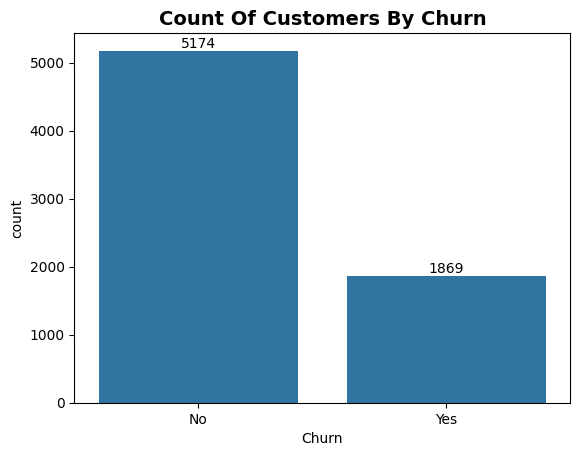

In [ ]:
ax=sns.countplot(x=data["Churn"])
ax.bar_label(ax.containers[0])
plt.title("Count Of Customers By Churn",fontsize=14,fontweight = "bold")
plt.show()

In [ ]:
gb = data.groupby("Churn").agg({"Churn":"count"})
gb

,Churn
Churn,
No,5174
Yes,1869


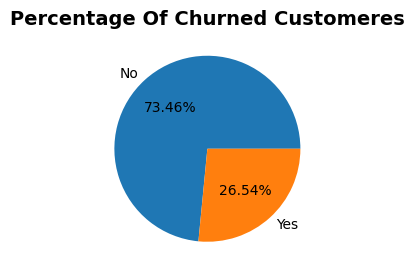

In [ ]:
plt.figure(figsize=(3,4))
gb=data.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb["Churn"],labels=gb.index,autopct = "%1.2f%%")
plt.title("Percentage Of Churned Customeres", fontsize=14,fontweight="bold")
plt.show()

* From the given pie chart we can conclude that 26.54% of our customers have churned out now let's explore the reson behind it

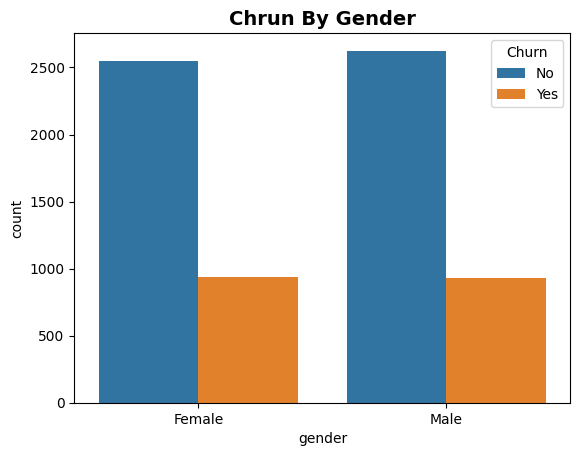

In [ ]:
sns.countplot(x="gender",data=data, hue= "Churn")
plt.title("Chrun By Gender", fontsize=14,fontweight="bold")
plt.show()

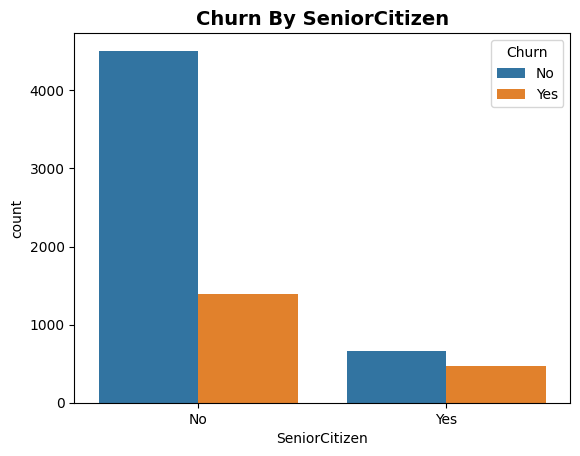

In [ ]:
sns.countplot(data=data,x="SeniorCitizen",hue="Churn")
plt.title("Churn By SeniorCitizen",fontsize=14,fontweight="bold")
plt.show()

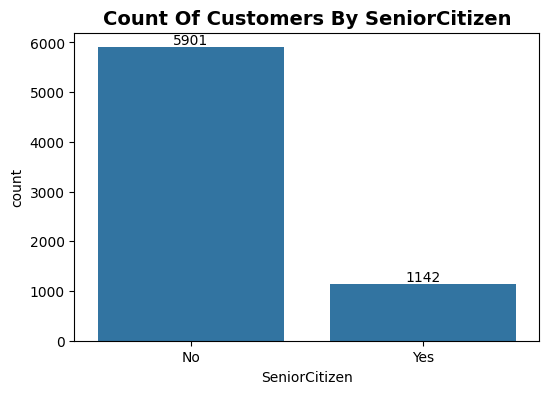

In [ ]:
plt.figure(figsize=(6,4))
ax =sns.countplot(data=data,x="SeniorCitizen")
plt.title("Count Of Customers By SeniorCitizen",fontsize=14,fontweight="bold")
ax.bar_label(ax.containers[0])
plt.show()

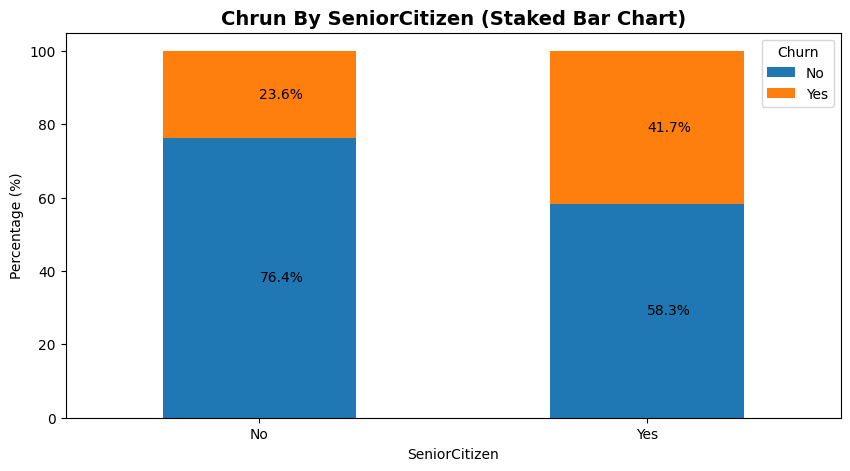

In [ ]:
total_count = data.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack() * 100
fig,ax=plt.subplots(figsize=(10,5))
total_count.plot(kind="bar",stacked= True,ax=ax)

for p in ax.patches:
  width,height = p.get_width(),p.get_height()
  x,y= p.get_xy()
  ax.text(x + width/2, y+ height/2,f"{height:.1f}%", va="center")

plt.title("Chrun By SeniorCitizen (Staked Bar Chart)", fontsize=14,fontweight="bold")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn", loc="upper right")
plt.show()

* Comparative a greater pecentage of people in SeniorCitizen category have chruned

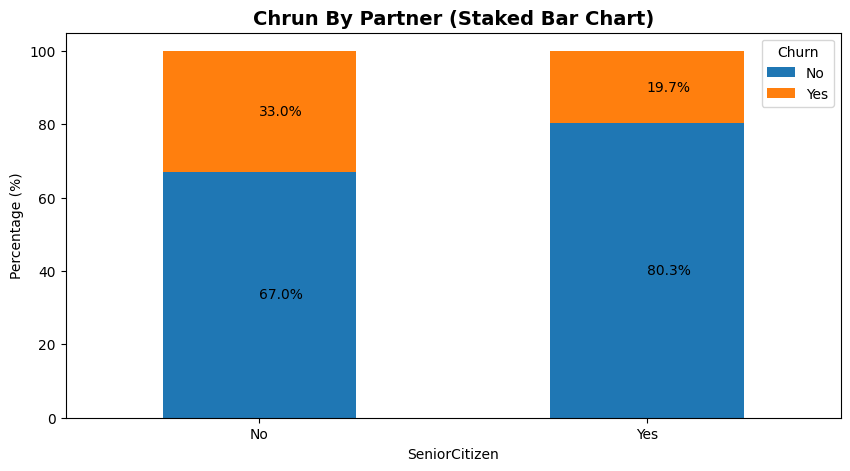

In [ ]:
total_count = data.groupby("Partner")["Churn"].value_counts(normalize=True).unstack() * 100
fig,ax=plt.subplots(figsize=(10,5))
total_count.plot(kind="bar",stacked= True,ax=ax)

for p in ax.patches:
  width,height = p.get_width(),p.get_height()
  x,y= p.get_xy()
  ax.text(x + width/2, y+ height/2,f"{height:.1f}%", va="center")

plt.title("Chrun By Partner (Staked Bar Chart)", fontsize=14,fontweight="bold")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn", loc="upper right")
plt.show()

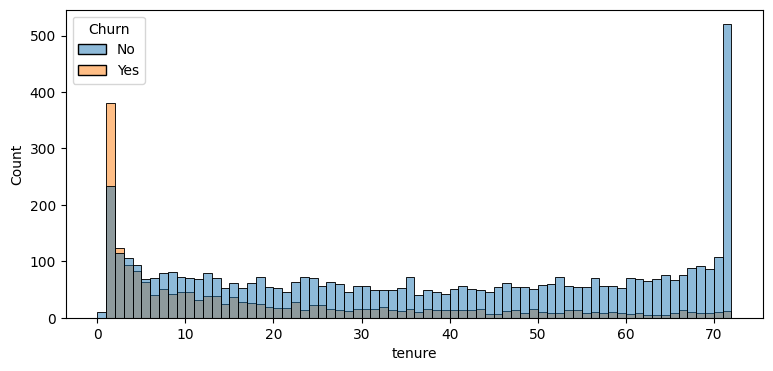

In [ ]:
plt.figure(figsize=(9,4))
sns.histplot(x="tenure", data=data,bins=72, hue="Churn")
plt.show()

* People who have used our services for a long time have stayed and people who have used our services 1 or 2 months have churned

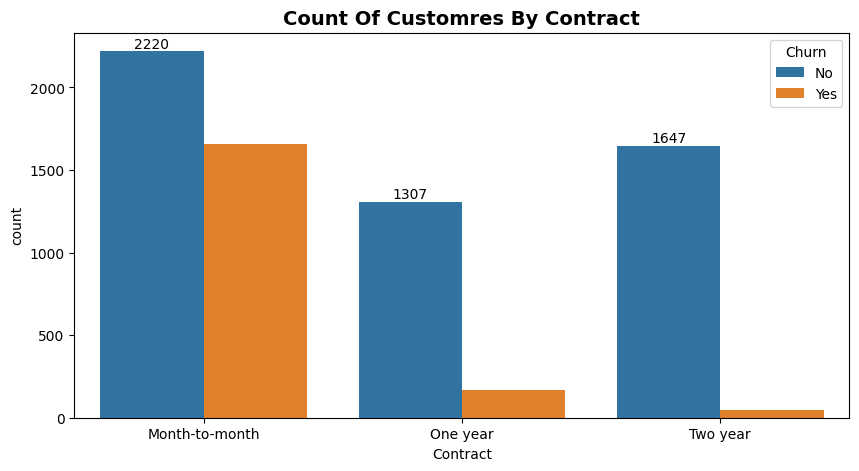

In [ ]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=data,x="Contract",hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count Of Customres By Contract",fontsize=14,fontweight="bold")
plt.show()

* People who have month to month contract are likeky to churn them from those who have  1 or 2 years or Contract

In [ ]:
data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

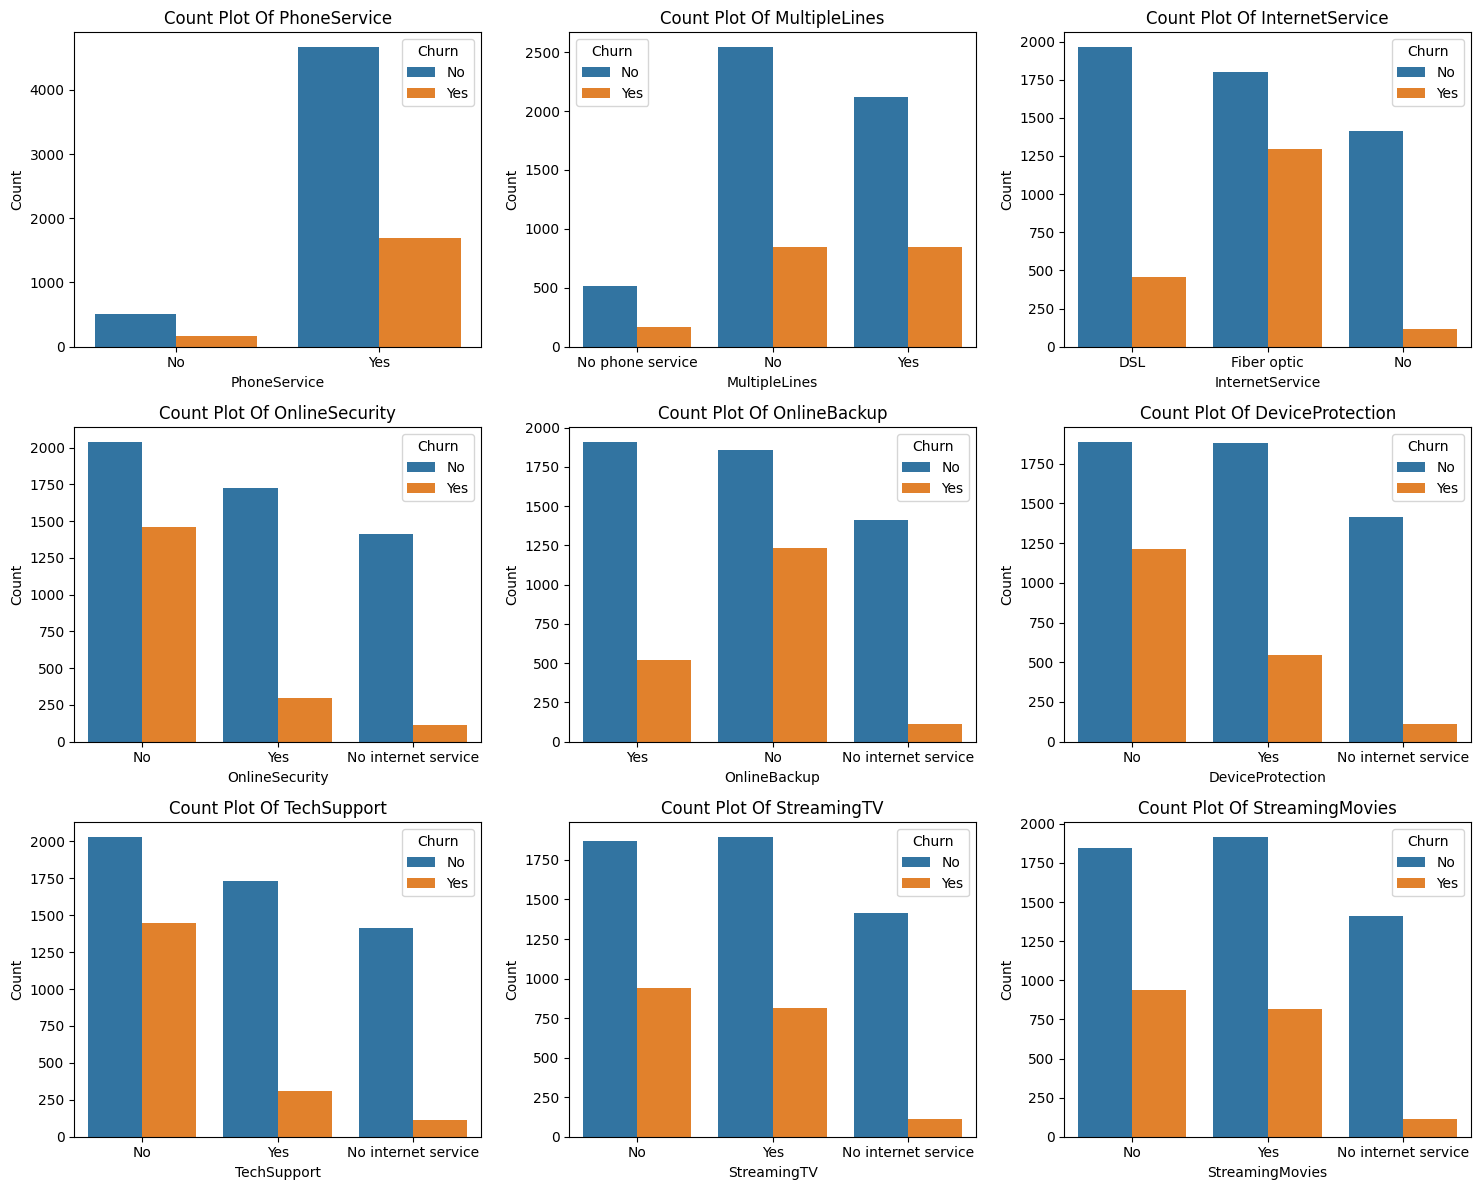

In [ ]:
columns=['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']

n_cols=3
n_rows= (len(columns) + n_cols-1)// n_cols
fig,axes=plt.subplots(n_rows,n_cols,figsize=(15,n_rows*4))
axes=axes.flatten()

for i, col in enumerate(columns):
  sns.countplot(x=col,data=data,ax=axes[i],hue=data["Churn"])
  axes[i].set_title(f"Count Plot Of {col}")
  axes[i].set_xlabel(col)
  axes[i].set_ylabel("Count")


for j in range(i + 1,len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* The majority of customers who do not churn tend to have services like PhoneService,InternetService(particularly DSL), and OnlineSecurity enabled. For Servic like OnlineBakup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not unavailable.

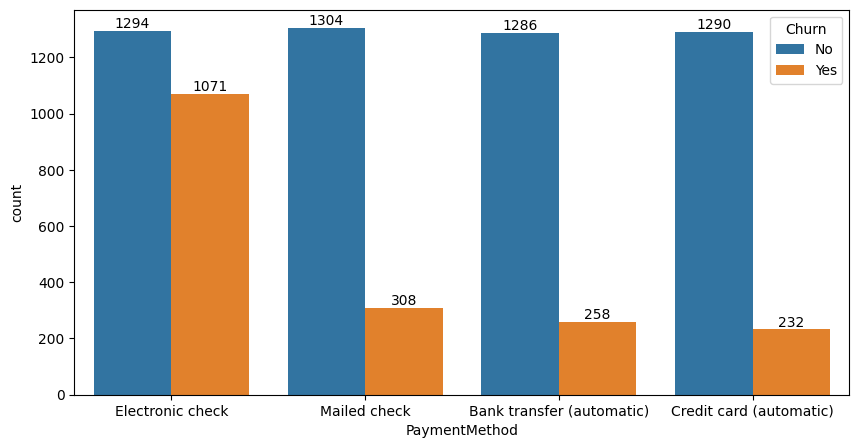

In [ ]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=data,x="PaymentMethod", hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

* Customer is likely to churn when he is using Electronic check as a Payment Method.

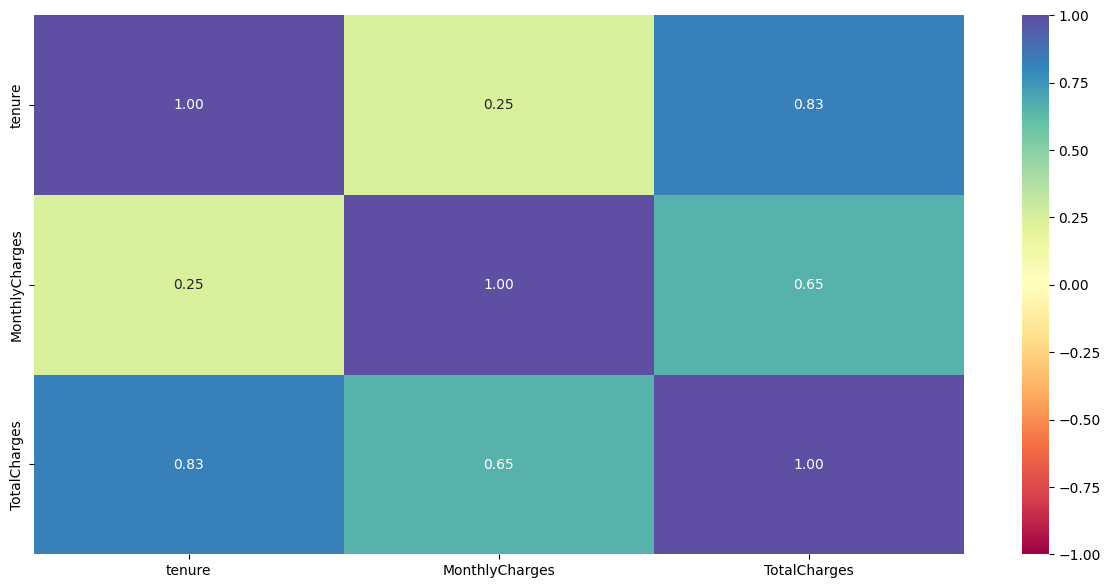

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

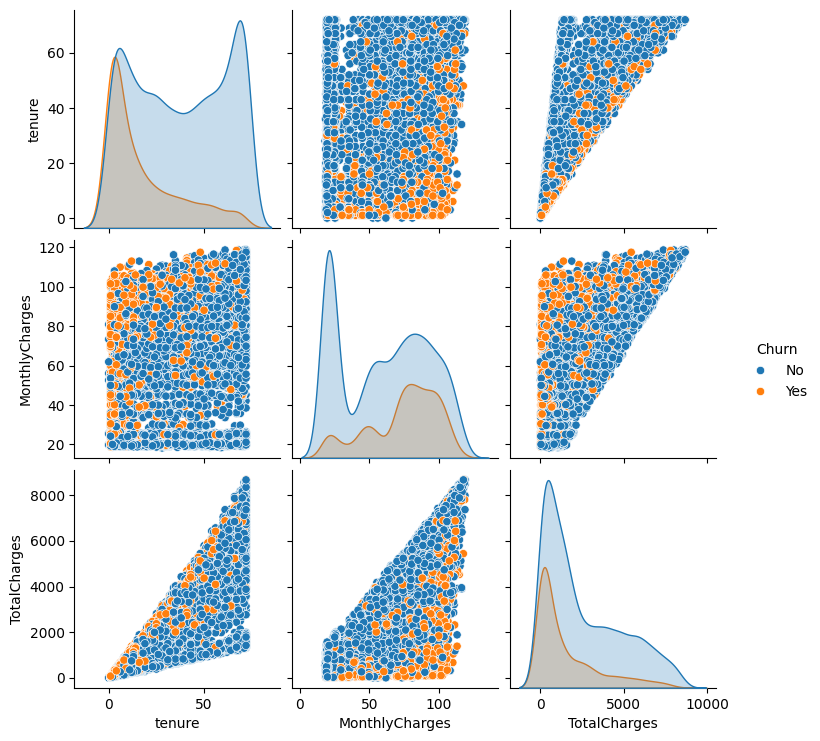

In [ ]:
sns.pairplot(data, hue="Churn")
plt.show()

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 88)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Churn            No   Yes   All
SeniorCitizen                  
All            5174  1869  7043
No             4508  1393  5901
Yes             666   476  1142
----------------------------------------------------------------------------------------


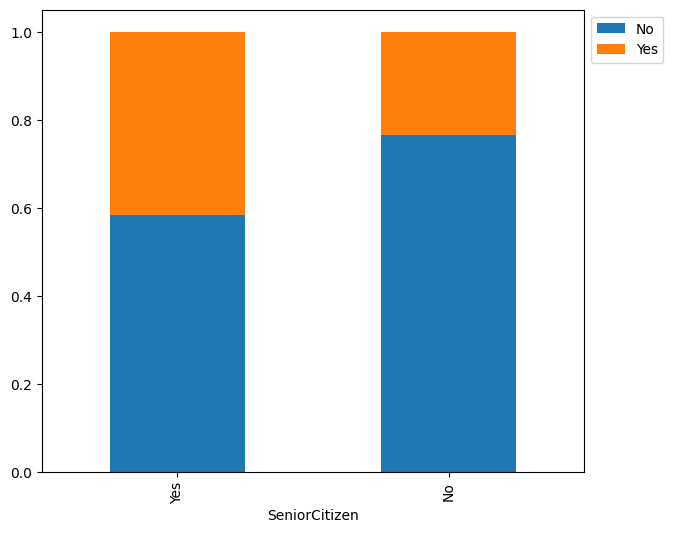

In [ ]:
stacked_barplot(data, "SeniorCitizen", "Churn")

Churn      No   Yes   All
Partner                  
All      5174  1869  7043
No       2441  1200  3641
Yes      2733   669  3402
----------------------------------------------------------------------------------------


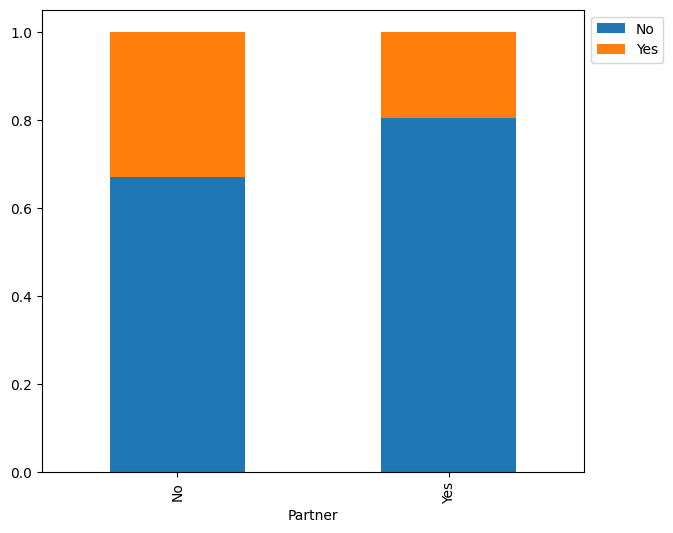

In [ ]:
stacked_barplot(data, "Partner", "Churn")

Churn         No   Yes   All
Dependents                  
All         5174  1869  7043
No          3390  1543  4933
Yes         1784   326  2110
----------------------------------------------------------------------------------------


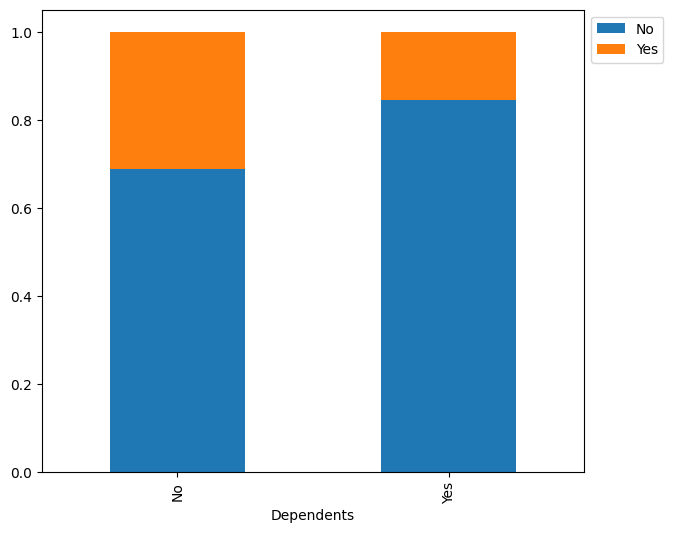

In [ ]:
stacked_barplot(data, "Dependents", "Churn")

Churn           No   Yes   All
PhoneService                  
All           5174  1869  7043
Yes           4662  1699  6361
No             512   170   682
----------------------------------------------------------------------------------------


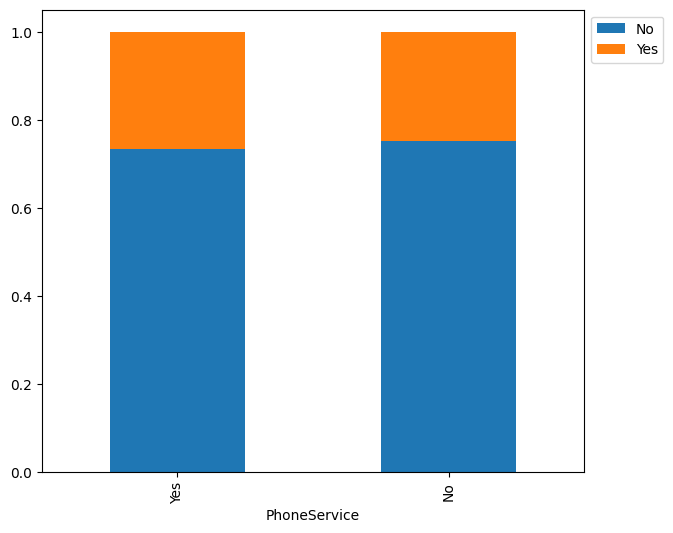

In [ ]:
stacked_barplot(data, "PhoneService", "Churn")